In [1]:
import pandas as pd
import os
from pathlib import Path  
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import cv2
import numpy as np
import shutil
from skimage import measure
from scipy import stats
import csv


In [2]:
model_name="Segformer"
HOME_DIR = Path("C:/Users/xiaoh/Desktop/3rd-Paper/Segmentation_Pipeline/outputs/Segformer_qualitative_results")
PREDICTIONS_DIR = Path(os.path.join(HOME_DIR,"Predictions") )
INPUT_MARTENSITE_PATH = Path(os.path.join(PREDICTIONS_DIR,"martensite")  )
INPUT_BAINITE_PATH = Path(os.path.join(PREDICTIONS_DIR,"bainite") )
TEXT_FILE_PATH = Path("C:/Users/xiaoh/Desktop/3rd-Paper/Segmentation_Pipeline/data/SEM_images")
MERGED_IMAGES_PATH = Path(os.path.join(PREDICTIONS_DIR,"big_merged_images"))
OUTPUT_DIR = Path(os.path.join(PREDICTIONS_DIR,"aspect_ratio_analysis"))

In [3]:
STEEL_TYPE_PATHS = {
    'N5325BAINITE': INPUT_BAINITE_PATH,
    'N5440MARTENSITE': INPUT_MARTENSITE_PATH
}

In [4]:
TILE_HEIGHT = 512
TILE_WIDTH = 512
LOWER_BOUND_COLOR = np.array([210, 210, 0])
UPPER_BOUND_COLOR = np.array([255, 255, 80])
NM_PER_PIXEL_BASE_MAG = 61.8 
MIN_PRECIPITATE_PIXEL_AREA = 30
EXCLUDED_MAGNIFICATION = 2500
FIGURE_DPI = 600

In [5]:
  

STEEL_TYPES = {
    "N5325BAINITE": Path(os.path.join(MERGED_IMAGES_PATH,"N5325BAINITE")) ,
    "N5440MARTENSITE": Path(os.path.join(MERGED_IMAGES_PATH,"N5440MARTENSITE"))
}
CONTOUR_AREA_RANGE = (50, 10000000)
BOX_COLOR_BGR = (106, 106, 255)

In [6]:
def load_images_from_folder(folder_path):
    images = {}
    image_extensions = ['.png', '.jpg', '.jpeg', '.gif', '.svg']
    for file_path in folder_path.iterdir():
        if file_path.suffix.lower() in image_extensions:
            img = cv2.imread(str(file_path))
            if img is not None:
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                images[file_path.name] = img_rgb
    return images

In [7]:
def get_image_size_from_df(name, df) :
    image_size = {}
    for _, row in df.iterrows():
        key = f"{name}_{row.iloc[3]}"
        size = (row.iloc[11], row.iloc[12])
        image_size[key] = size
    return image_size

In [8]:
def resize_images(images, size_map):
    resized_images = {}
    for name, img in images.items():
        if name in size_map:
            target_height, target_width = size_map[name]
            resized_images[name] = cv2.resize(img, (target_width, target_height))
    return resized_images

In [9]:
def merge_tiles_to_image(tiles, image_size_map, tile_h, tile_w):
    stitched_images = {}
    for base_name, (full_h, full_w) in image_size_map.items():
        print(f"Stitching image: {base_name}, target size: {full_h}x{full_w}")
        num_channels = 3 
        first_tile = next(iter(tiles.values()), None)
        if first_tile is not None:
            if first_tile.ndim == 3:
                num_channels = first_tile.shape[2]
            else: 
                num_channels = 1
        if num_channels > 1:
            stitched_image = np.zeros((full_h, full_w, num_channels), dtype=np.uint8)
        else:
            stitched_image = np.zeros((full_h, full_w), dtype=np.uint8)
        num_y = int(np.ceil(full_h / tile_h))
        num_x = int(np.ceil(full_w / tile_w))
        for j in range(num_y):
            for i in range(num_x):
                tile_name = f"{base_name}_{j}_{i}.png"
                tile = tiles.get(tile_name)
                if tile is None:
                    print(f"Warning: Tile {tile_name} not found! Area will be black.")
                    continue 
                y_start = j * tile_h
                x_start = i * tile_w
            
                h_to_copy = min(tile.shape[0], full_h - y_start)
                w_to_copy = min(tile.shape[1], full_w - x_start)
        
                stitched_image[y_start : y_start + h_to_copy, x_start : x_start + w_to_copy] = \
                    tile[-h_to_copy:, -w_to_copy:]
        
        stitched_images[base_name] = stitched_image
        
    return stitched_images

In [10]:
def calculate_precipitate_sizes(image_name: str, img: np.ndarray) -> list:
    try:
        magnification = int(image_name.split('X')[0].split('-')[1])
    except (IndexError, ValueError):
        print(f"Warning: Could not parse magnification from '{image_name}'. Skipping size calculation.")
        return []

    if magnification == EXCLUDED_MAGNIFICATION:
        return []

 
    mask = cv2.inRange(img, LOWER_BOUND_COLOR, UPPER_BOUND_COLOR)
    
 
    labels = measure.label(mask)
    props = measure.regionprops(labels)
    
    pixel_areas = [prop.area for prop in props if prop.area >= MIN_PRECIPITATE_PIXEL_AREA]
    
 
    conversion_factor = (NM_PER_PIXEL_BASE_MAG / magnification)**2
    physical_areas = [area * conversion_factor * 10**6 for area in pixel_areas]
    
    return physical_areas



In [11]:
def analyze_carbide_shapes(image_path: Path) -> tuple[list, list]:
    # Load image in BGR format
    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None:
        print(f"Warning: Could not read image file: {image_path}")
        return [], []
 
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    _, binary_mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Find contours of all distinct shapes in the mask
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)

    aspect_ratios = []
    bounding_boxes = []
    min_area, max_area = CONTOUR_AREA_RANGE

    for contour in contours:
        area = cv2.contourArea(contour)
        if not (min_area < area < max_area):
            continue
 
        rect = cv2.minAreaRect(contour)
        box_points = cv2.boxPoints(rect)
        box = np.int0(box_points)
 
        width, height = rect[1]
        if width <= 0 or height <= 0:
            continue
 
        aspect_ratio = max(width, height) / min(width, height)
        aspect_ratios.append(aspect_ratio)
        bounding_boxes.append(box)

    return aspect_ratios, bounding_boxes

In [12]:
def create_highlighted_image(original_image_path: Path, boxes: list) -> np.ndarray:
    img_bgr = cv2.imread(str(original_image_path))
    cv2.drawContours(img_bgr, boxes, -1, BOX_COLOR_BGR, 2)
    return img_bgr


In [13]:
def process_steel_type(steel_name: str, image_folder: Path) -> list:
    print(f"\nProcessing steel type: {steel_name}...")
    image_folder=Path(image_folder)
    all_ratios = []

    # Prepare the output directory for this steel type's highlighted images
    output_image_dir = Path(os.path.join(OUTPUT_DIR,steel_name.replace(" ", "_")))

    output_image_dir.mkdir(parents=True, exist_ok=True)

    image_paths = [p for p in image_folder.glob("*.png") if int(p.name.split('-')[-1].split('_')[0].split('X')[0])  != EXCLUDED_MAGNIFICATION]

    for image_path in image_paths:
        ratios, boxes = analyze_carbide_shapes(image_path)
        
        if ratios:
            all_ratios.extend(ratios)
            
            # Create and save the highlighted image for visual verification
            highlighted_img = create_highlighted_image(image_path, boxes)
            save_path = output_image_dir / f"{image_path.stem}_highlighted.png"
            cv2.imwrite(str(save_path), highlighted_img)


    return all_ratios

In [14]:
def bootstrap_ci(data, statistic_func, n_bootstrap=2000, confidence_level=0.95):
    data = np.array(data)
 
    if len(data) == 0:
        return np.nan, (np.nan, np.nan)
        
    bootstrap_stats = []
    n_size = len(data)
    for _ in range(n_bootstrap):
        resample_indices = np.random.choice(n_size, size=n_size, replace=True)
        resample = data[resample_indices]
        stat = statistic_func(resample)
        bootstrap_stats.append(stat)
    point_estimate = statistic_func(data)
    alpha = (1 - confidence_level) / 2.0
    lower_bound = np.percentile(bootstrap_stats, alpha * 100)
    upper_bound = np.percentile(bootstrap_stats, (1 - alpha) * 100)
    
    return point_estimate, (lower_bound, upper_bound)

In [15]:
def plot_size_distribution(merged_size_list):
    size_lb = merged_size_list['N5325BAINITE']
    size_tm = merged_size_list['N5440MARTENSITE']

 
    size_lb_tail = [number for number in size_lb if number > 100000]
    size_tm_tail = [number for number in size_tm if number > 100000]

    data_lb = size_lb
    data_tm = size_tm

    mean_lb, mean_ci_lb = bootstrap_ci(data_lb, np.mean)
    median_lb, median_ci_lb = bootstrap_ci(data_lb, np.median)

    mean_tm, mean_ci_tm = bootstrap_ci(data_tm, np.mean)
    median_tm, median_ci_tm = bootstrap_ci(data_tm, np.median)


    plt.rcParams['font.family'] = 'Times New Roman'
    plt.rcParams['font.size'] = 20

    color_lb = '#779de2'
    color_tm = '#f28be5'
    color_mean = 'green'
    color_median = 'red'

    fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
    ax1, ax2, ax3, ax4 = axes.flatten()

    bins = np.logspace(3, 9, 30)


    plot_configs = [
        # (a) LB - Full View
        {'ax': ax1, 'plot_data': data_lb, 'mean': mean_lb, 'mean_ci': mean_ci_lb, 'median': median_lb, 'median_ci': median_ci_lb, 'color': color_lb, 'label': '(a) LB', 'is_tail': False},
        # (c) LB - Tail View
        {'ax': ax2, 'plot_data': size_lb_tail, 'mean': mean_lb, 'mean_ci': mean_ci_lb, 'median': median_lb, 'median_ci': median_ci_lb, 'color': color_lb, 'label': '(c) LB', 'is_tail': True},
        # (b) TM - Full View
        {'ax': ax3, 'plot_data': data_tm, 'mean': mean_tm, 'mean_ci': mean_ci_tm, 'median': median_tm, 'median_ci': median_ci_tm, 'color': color_tm, 'label': '(b) TM', 'is_tail': False},
        # (d) TM - Tail View
        {'ax': ax4, 'plot_data': size_tm_tail, 'mean': mean_tm, 'mean_ci': mean_ci_tm, 'median': median_tm, 'median_ci': median_ci_tm, 'color': color_tm, 'label': '(d) TM', 'is_tail': True}
    ]

    for config in plot_configs:
        ax = config['ax']
        plot_data = config['plot_data']

        counts, _, _ = ax.hist(plot_data, bins=bins, color=config['color'], edgecolor='white', linewidth=1.2,alpha=0.5)

        ax.set_xscale('log')
        ax.set_ylabel('Number of carbides')

 
        max_count = np.max(counts) if len(counts) > 0 else 0
        if not config['is_tail']:
            ax.set_ylim(0, max_count * 1.1)
        else:
            ax.set_ylim(0, max_count * 1.2 if max_count > 0 else 10)

        ax.grid(True, which='both', axis='both', linestyle='--', linewidth=0.5)

 
        mean_val, mean_ci = config['mean'], config['mean_ci']
        median_val, median_ci = config['median'], config['median_ci']

 
        if not config['is_tail']:

            ax.axvline(mean_val, color=color_mean, linestyle='--', linewidth=2, zorder=2)
            ax.axvline(median_val, color=color_median, linestyle='--', linewidth=2, zorder=2)

            ax.axvspan(mean_ci[0], mean_ci[1], color=color_mean, alpha=0.2, zorder=1)
            ax.axvspan(median_ci[0], median_ci[1], color=color_median, alpha=0.2, zorder=1)

            mean_um2, mean_ci_um2 = mean_val/1e6, (mean_ci[0]/1e6, mean_ci[1]/1e6)
            median_um2, median_ci_um2 = median_val/1e6, (median_ci[0]/1e6, median_ci[1]/1e6)

            y_max = ax.get_ylim()[1]

 
            ax.text(mean_val * 1.5, y_max * 0.75, 
                    f'Mean={mean_um2:.2f}, 95% CI: [{mean_ci_um2[0]:.2f}, {mean_ci_um2[1]:.2f}] μm²',
                    color=color_mean, fontsize=16, verticalalignment='center')
            ax.text(median_val * 1.5, y_max * 0.6, 
                    f'Median={median_um2:.4f}, 95% CI: [{median_ci_um2[0]:.4f}, {median_ci_um2[1]:.4f}] μm²',
                    color=color_median, fontsize=16, verticalalignment='center')

 
        ax.text(0.95, 0.95, config['label'], transform=ax.transAxes,
                fontsize=20, verticalalignment='top', horizontalalignment='right')

 
    for ax in [ax3, ax4]:
        ax.set_xlabel('Carbide Size (nm²)')

    plt.tight_layout(pad=2.0)
    size_fig_path=os.path.join(HOME_DIR,"carbide_size_distribution_with_CI.png")
    plt.savefig(size_fig_path, dpi=300)
    print(f"the size distribution figure has been saved to {size_fig_path}")
    plt.show()

In [16]:

def aspect_ratio_plot(aspect_ratio_data):
    data_lb = aspect_ratio_data['N5325BAINITE']
    data_tm = aspect_ratio_data['N5440MARTENSITE']


    font_size = 16

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
 
    axes[0, 0].scatter(np.arange(len(data_lb)), data_lb, 
                       marker='^', s=30, facecolors='none', edgecolors='royalblue', alpha=0.7)
    axes[0, 0].set_ylabel("Carbide Aspect Ratio", fontsize=font_size)
    axes[0, 0].text(0.05, 0.95, '(a) LB', transform=axes[0, 0].transAxes, 
                    fontsize=font_size, va='top', ha='left')
 
    axes[1, 0].scatter(np.arange(len(data_tm)), data_tm, 
                       marker='o', s=30, facecolors='none', edgecolors='hotpink', alpha=0.3)
    axes[1, 0].set_xlabel("Carbide Index", fontsize=font_size)
    axes[1, 0].set_ylabel("Carbide Aspect Ratio", fontsize=font_size)
    axes[1, 0].text(0.05, 0.95, '(b) TM', transform=axes[1, 0].transAxes,
                    fontsize=font_size, va='top', ha='left')
 

    axes[0, 1].hist(data_lb, bins=np.linspace(0, 6, 20), color='royalblue',
                    edgecolor='gray', hatch='//', alpha=0.7)
    axes[0, 1].set_ylabel("Number of carbides", fontsize=font_size)
    axes[0, 1].text(0.95, 0.95, '(c) LB', transform=axes[0, 1].transAxes,
                    fontsize=font_size, va='top', ha='right')



    mean_lb, mean_ci_lb = bootstrap_ci(data_lb, np.mean)
    median_lb, median_ci_lb = bootstrap_ci(data_lb, np.median)

    mean_tm, mean_ci_tm = bootstrap_ci(data_tm, np.mean)
    median_tm, median_ci_tm = bootstrap_ci(data_tm, np.median)
 
    axes[0, 1].axvline(mean_lb, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_lb:.2f}')
    axes[0, 1].axvspan(mean_ci_lb[0], mean_ci_lb[1], color='red', alpha=0.2, label=f'Mean 95% CI: [{np.round(mean_ci_lb[0],2)}, {np.round(mean_ci_lb[1],2)}]')
    # 绘制中位数
    axes[0, 1].axvline(median_lb, color='green', linestyle=':', linewidth=2, label=f'Median: {median_lb:.2f}')
    axes[0, 1].axvspan(median_ci_lb[0], median_ci_lb[1], color='green', alpha=0.2, label=f'Median 95% CI: [{np.round(median_ci_lb[0],2)}, {np.round(median_ci_lb[1],2)}]')

    axes[0, 1].legend(fontsize=13)  

    # (d) TM 直方图

    axes[1, 1].hist(data_tm, bins=np.linspace(0, 6, 20), color='hotpink',
                    edgecolor='gray', hatch='//', alpha=0.3)
    axes[1, 1].set_xlabel("Aspect ratio", fontsize=font_size)
    axes[1, 1].set_ylabel("Number of carbides", fontsize=font_size)
    axes[1, 1].text(0.95, 0.95, '(d) TM', transform=axes[1, 1].transAxes,
                    fontsize=font_size, va='top', ha='right')

    axes[1, 1].axvline(mean_tm, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_tm:.2f}')
    axes[1, 1].axvspan(mean_ci_tm[0], mean_ci_tm[1], color='red', alpha=0.2, label=f'Mean 95% CI: [{np.round(mean_ci_tm[0],2)}, {np.round(mean_ci_tm[1],2)}]')
 
    axes[1, 1].axvline(median_tm, color='green', linestyle=':', linewidth=2, label=f'Median: {median_tm:.2f}')
    axes[1, 1].axvspan(median_ci_tm[0], median_ci_tm[1], color='green', alpha=0.2, label=f'Median 95% CI: [{np.round(median_ci_tm[0],2)}, {np.round(median_ci_tm[1],2)}]')

    axes[1, 1].legend(fontsize=13)  
 
    for ax in [axes[0, 0], axes[1, 0]]:
        ax.set_ylim(0, 15)

    for ax in [axes[0, 1], axes[1, 1]]:
        ax.set_xlim(1, 6)

    for ax in [axes[0, 0], axes[1, 0]]:
        ax.set_xlim(0, 30000)

    size_fig_path=os.path.join(HOME_DIR,"carbide_aspect_ratio_distribution_with_CI.png")
    print(f"The figure has been saved to {size_fig_path}")
    plt.savefig(size_fig_path, dpi=300)
    plt.show()

In [17]:
def print_sizes_aspect_ratios_to_csv(merged_size_list,aspect_ratio_data,output_dir,model_name):
    
    output_df = pd.DataFrame({name: pd.Series(sizes) for name, sizes in merged_size_list.items()})
    output_df.to_csv(output_dir /f"Size_Distribution_{model_name}.csv", index=False)
    print("\nAnalysis complete. Results of sizes have been saved to CSV and PNG files.")
      
    output_df = pd.DataFrame({name: pd.Series(sizes) for name, sizes in aspect_ratio_data.items()})
    output_df.to_csv(output_dir / f"Aspect_Ratio_Distribution_{model_name}.csv", index=False)
    print("\nAnalysis complete. Results of aspect ratios have been saved to CSV and PNG files.")
    
    with open(os.path.join(output_dir,f'Size_and_Aspect_ratio_p_values{model_name}.csv'), "w", newline='') as csv_file:
        writer = csv.writer(csv_file)

        t_stat, p_val = stats.ttest_ind(aspect_ratio_data['N5325BAINITE'], aspect_ratio_data['N5440MARTENSITE'])

        writer.writerow([f"t-statistic for carbide aspect ratios: {t_stat}"]) 
        writer.writerow([f"p-value for carbide aspect ratios: {p_val}"])     

        if p_val < 0.05:
            writer.writerow(["Conclusion: Reject the null hypothesis. The difference between the group means is statistically significant."]) 
        else:
            writer.writerow(["Conclusion: Fail to reject the null hypothesis. There is no statistically significant difference between the groups."]) 


        writer.writerow([]) 

        t_stat, p_val = stats.ttest_ind(merged_size_list['N5325BAINITE'], merged_size_list['N5440MARTENSITE'])

        writer.writerow([f"t-statistic for carbide sizes: {t_stat}"]) 
        writer.writerow([f"p-value for carbide sizes: {p_val}"])    

        if p_val < 0.05:
            writer.writerow(["Conclusion: Reject the null hypothesis. The difference between the group means is statistically significant."]) 
        else:
            writer.writerow(["Conclusion: Fail to reject the null hypothesis. There is no statistically significant difference between the groups."]) 

        print(f"File f'Size_and_Aspect_ratio_p_values{model_name}.csv' has been written successfully.")


In [18]:
dataframe_dict = {}
original_dataframe = {}
for file_path in TEXT_FILE_PATH.glob('*_resized.txt'):
    df = pd.read_csv(file_path, header=None, delimiter=r"\s+")
    name = file_path.name.split('_')[0]
    dataframe_dict[name] = get_image_size_from_df(name, df)

In [19]:
for file_path in TEXT_FILE_PATH.glob('*_without_resize.txt'):
    df = pd.read_csv(file_path, header=None, delimiter=r"\s+")
    name = "".join(file_path.name.split('_')[0])
    print(name)
    original_dataframe[name] = get_image_size_from_df(name, df)


42CrMo4BAINITE
N5325BAINITE
N5440MARTENSITE


In [20]:
all_resized_images = {}
for steel_name, folder_path in STEEL_TYPE_PATHS.items():
    print(f"\nProcessing steel type: {steel_name}")
    print(f"\folder path type: {folder_path}")
    image_tiles = load_images_from_folder(folder_path)
    merged_images = merge_tiles_to_image(
        image_tiles, dataframe_dict.get(steel_name, {}), TILE_HEIGHT, TILE_WIDTH
    )
    all_resized_images[steel_name] = resize_images(
        merged_images, original_dataframe.get(steel_name, {})
    )


Processing steel type: N5325BAINITE
older path type: C:\Users\xiaoh\Desktop\3rd-Paper\Segmentation_Pipeline\outputs\Segformer_qualitative_results\Predictions\bainite
Stitching image: N5325BAINITE_0.2-2500X_004, target size: 7072x8192
Stitching image: N5325BAINITE_0.35-5000X_005, target size: 3536x4096
Stitching image: N5325BAINITE_0.38-6000X_003, target size: 2946x3413
Stitching image: N5325BAINITE_0.38-6000X_008, target size: 2946x3413
Stitching image: N5325BAINITE_0.43-10000X_002, target size: 1768x2048
Stitching image: N5325BAINITE_0.43-10000X_007, target size: 1768x2048
Stitching image: N5325BAINITE_0.43-15000X_001, target size: 1178x1365
Stitching image: N5325BAINITE_0.43-15000X_006, target size: 1178x1365
Stitching image: N5325BAINITE_0.45-20000X, target size: 884x1024
Stitching image: N5325BAINITE_0.5-10000X_010, target size: 1768x2048
Stitching image: N5325BAINITE_0.5-15000X_009, target size: 1178x1365
Stitching image: N5325BAINITE_0.5-6000X_011, target size: 2946x3413

Proce

In [21]:
 
if MERGED_IMAGES_PATH.exists():
    shutil.rmtree(MERGED_IMAGES_PATH)
MERGED_IMAGES_PATH.mkdir(parents=True)

for steel_name, images in all_resized_images.items():
    steel_output_dir = MERGED_IMAGES_PATH / steel_name
    steel_output_dir.mkdir()
    for image_name, img_data in images.items():
        # 将图像从RGB转回BGR以供cv2.imwrite保存
        img_bgr = cv2.cvtColor(img_data, cv2.COLOR_RGB2BGR)
        save_path = steel_output_dir / f"{image_name}.png"
        cv2.imwrite(str(save_path), img_bgr)

In [22]:
merged_size_list = {}
for steel_name, images in all_resized_images.items():
    all_sizes = []
    for image_name, img_data in images.items():
        print(f"Analyzing precipitates in: {image_name}")
        sizes = calculate_precipitate_sizes(image_name, img_data)
        all_sizes.extend(sizes)
    merged_size_list[steel_name] = np.array(all_sizes)

Analyzing precipitates in: N5325BAINITE_0.2-2500X_004
Analyzing precipitates in: N5325BAINITE_0.35-5000X_005
Analyzing precipitates in: N5325BAINITE_0.38-6000X_003
Analyzing precipitates in: N5325BAINITE_0.38-6000X_008
Analyzing precipitates in: N5325BAINITE_0.43-10000X_002
Analyzing precipitates in: N5325BAINITE_0.43-10000X_007
Analyzing precipitates in: N5325BAINITE_0.43-15000X_001
Analyzing precipitates in: N5325BAINITE_0.43-15000X_006
Analyzing precipitates in: N5325BAINITE_0.45-20000X
Analyzing precipitates in: N5325BAINITE_0.5-10000X_010
Analyzing precipitates in: N5325BAINITE_0.5-15000X_009
Analyzing precipitates in: N5325BAINITE_0.5-6000X_011
Analyzing precipitates in: N5440MARTENSITE_0.43-6000X_015
Analyzing precipitates in: N5440MARTENSITE_0.43-6000X_021
Analyzing precipitates in: N5440MARTENSITE_0.45-10000X_017
Analyzing precipitates in: N5440MARTENSITE_0.45-5000X_022
Analyzing precipitates in: N5440MARTENSITE_0.48-10000X_014
Analyzing precipitates in: N5440MARTENSITE_0.48-1

the size distribution figure has been saved to C:\Users\xiaoh\Desktop\3rd-Paper\Segmentation_Pipeline\outputs\Segformer_qualitative_results\carbide_size_distribution_with_CI.png


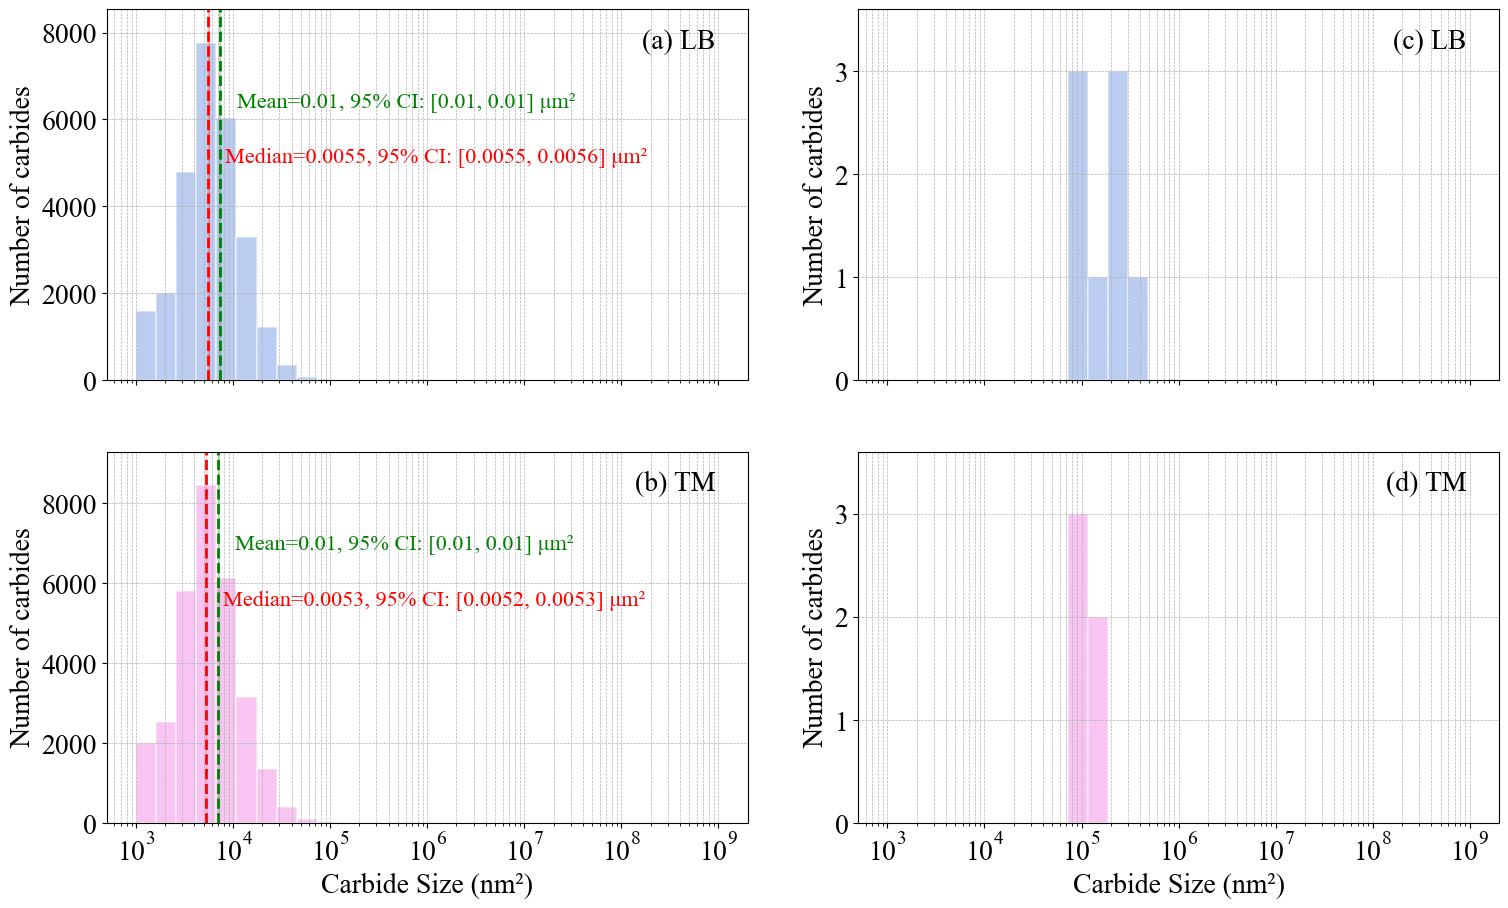

In [23]:
plot_size_distribution(merged_size_list)

In [24]:
if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True)

In [25]:
aspect_ratio_data = {}
for name, path in STEEL_TYPES.items():
    aspect_ratio_data[name] = process_steel_type(name, path)


Processing steel type: N5325BAINITE...


C:\Users\xiaoh\AppData\Local\Temp\ipykernel_8544\1496708182.py:25: DeprecationWarning: `np.int0` is a deprecated alias for `np.intp`.  (Deprecated NumPy 1.24)
  box = np.int0(box_points)



Processing steel type: N5440MARTENSITE...


The figure has been saved to C:\Users\xiaoh\Desktop\3rd-Paper\Segmentation_Pipeline\outputs\Segformer_qualitative_results\carbide_aspect_ratio_distribution_with_CI.png


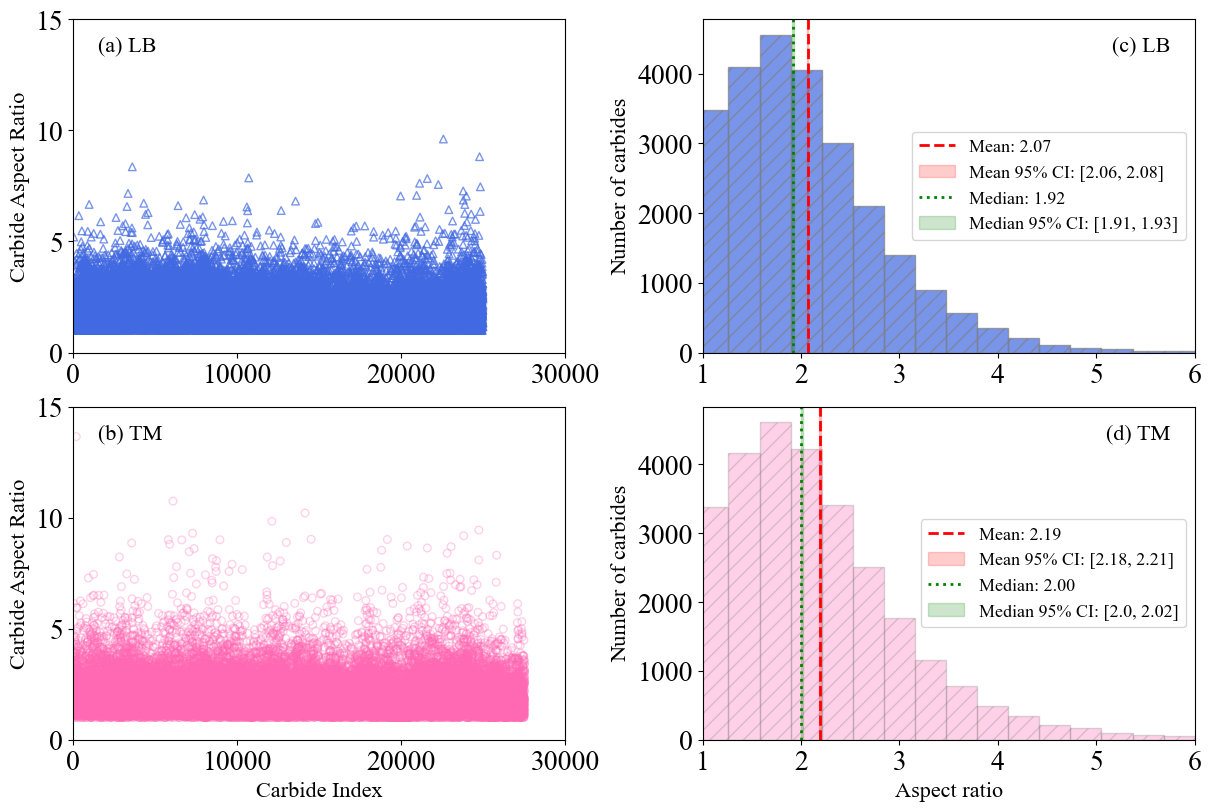

In [26]:
aspect_ratio_plot(aspect_ratio_data)

In [27]:
print_sizes_aspect_ratios_to_csv(merged_size_list,aspect_ratio_data,HOME_DIR,model_name)


Analysis complete. Results of sizes have been saved to CSV and PNG files.

Analysis complete. Results of aspect ratios have been saved to CSV and PNG files.
File f'Size_and_Aspect_ratio_p_valuesSegformer.csv' has been written successfully.
